## Import Libraries

In [1]:
import matplotlib.pylab as pl
import pandas as pd
import pickle
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error
import optuna
from sklearn.model_selection import KFold
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_optimization_history
import shap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

## Import dataset

In [2]:
#Raw df without manipulation, required for the Optuna
raw_df = pd.read_csv('(...)/PDRA_Processed_Data_OS.csv') #change this path for the path of the desired dataset
#Make df: the dataset that will be used for the model
df = raw_df.copy()
#drop irrelevant driver performance features. Change this according to the desired analysis.
df = df.drop(['crash', 'minTTC', 'totalGlanceTimeOther', 'TTC'], axis = 1)

df


,subNumber,Gender,driverTraining,eventNumber,Age,drivingExperience,reactionTime,AVR,attenD,euclideanGazeDispersion,gazeEntropy,yawGazeDispersion,pitchGazeDispersion,totalGlanceTimeDriverMirror,totalGlanceTimeInstrumentCluster,totalGlanceTimeOffRoad,totalGlanceTimeOnRoad,totalGlanceTimePassengerMirror,totalGlanceTimeRearMirror
0,3,1,0,0,37,12,2.75,1.24,0.00,0.13,0.50,0.22,0.19,0.000000,0.000000,0.000000,6.499910,0.0,0.0
1,4,1,0,0,27,9,2.57,2.19,3.00,0.01,2.60,0.12,0.09,0.000000,0.000000,3.000092,3.499991,0.0,0.0
2,4,1,0,1,27,9,1.90,2.19,0.00,0.01,2.15,0.14,0.06,0.000000,0.000000,2.976755,3.520544,0.0,0.0
3,4,1,0,2,27,9,2.63,2.19,0.00,0.03,1.86,0.22,0.15,0.000000,0.000000,3.587340,2.757942,0.0,0.0
4,4,1,0,3,27,9,2.00,2.19,0.00,0.04,1.06,0.29,0.15,0.000000,0.000000,5.784356,0.715487,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,32,1,1,3,25,8,1.62,4.66,2.26,0.06,2.15,0.17,0.19,0.000000,1.846824,3.043648,1.608153,0.0,0.0
101,33,0,1,0,39,18,0.38,1.33,0.00,0.07,2.40,0.22,0.15,0.567236,0.106263,0.000000,5.368379,0.0,0.0
102,33,0,1,1,39,18,1.20,1.33,2.35,0.01,2.53,0.10,0.06,0.000000,0.000000,2.955344,3.544664,0.0,0.0
103,33,0,1,2,39,18,1.13,1.33,0.00,0.14,1.46,0.36,0.22,0.695735,0.000000,5.174656,0.628127,0.0,0.0


In [3]:
#Assign the features that will be used in the model
feature_cols = df.columns[1:].to_list()
target_col = 'reactionTime'
feature_cols.remove ('reactionTime')

In [4]:
dict_keys = df.columns
# Define categorical and continuous columns
cat_names = [col for col in dict_keys 
             if df[col].dtype.name == 'category' or df[col].dtype == 'object']
cont_names = [col for col in dict_keys 
             if col not in cat_names and col != 'reactionTime']
#move categorical values to cat_names
#for example, eventNumber and TTC
cols_to_move = [
 'eventNumber',
 #'TTC',
 'driverTraining',
 'Gender',
    
]
cat_names.extend(cols_to_move)
cont_names = [col for col in cont_names if col not in cols_to_move]

#Z-transformation Scaling for the features of the model
class ScalingHandler:
    #in case standardization is not wanted, change the next scaling_method to 'MinMax'
    def __init__(self, scaling_method):
        self.scaling_method = scaling_method
        self.scaler = StandardScaler() if scaling_method == 'standard' else MinMaxScaler()

    def scale_data(self, train_data, test_data, cont_names):
        train_scaled = train_data.copy()
        test_scaled = test_data.copy()

        # Fit scaler on training data and transform both sets
        train_scaled[cont_names] = self.scaler.fit_transform(train_data[cont_names])
        test_scaled[cont_names] = self.scaler.transform(test_data[cont_names])

        return train_scaled, test_scaled

## Optuna function

In [5]:
def objective(trial):
    #in case standardization is not wanted, change the next scaling_method to 'MinMax'
    scaler = ScalingHandler(scaling_method='standard')
    params = {
        # Core Parameters
        'objective': 'reg:squarederror',  # for regression
        'booster': 'gbtree',
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 3, 1000),

        # Tree Parameters
        'max_depth': trial.suggest_int('max_depth', 1, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),

        # Sampling Parameters
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        # Regularization Parameters
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
    }

    #Here is where we define the number of splits for cross validation. It can be adjusted as see fit.
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(df[feature_cols])):
        train_fold = df.iloc[train_idx]
        valid_fold = df.iloc[valid_idx]
        train_scaled, val_scaled = scaler.scale_data(train_fold, valid_fold, cont_names)

        model = xgb.XGBRegressor(**params)
        model.fit(
            train_scaled[feature_cols],
            train_fold[target_col],
            eval_set=[(val_scaled[feature_cols], valid_fold[target_col])],
            verbose=False
        )

        pred = model.predict(val_scaled[feature_cols])
        rmse = np.sqrt(mean_squared_error(valid_fold[target_col], pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)

## Optimize hyperparameters

In [6]:
# Create study with pruner
study = optuna.create_study(
    direction='minimize',  # We want to minimize RMSE
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=50,
        interval_steps=20
    )
)

# Run optimization
#The n_trials can be adjusted as see fit. The original study used 5000.
study.optimize(objective, n_trials=5000, n_jobs=-1)  # n_jobs=-1 uses all cores

# Print results
print("Best trial:")
print("  RMSE: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-07-02 09:38:24,182] A new study created in memory with name: no-name-b3cdf7a4-2872-4318-a93e-6af9a1229a35
[I 2025-07-02 09:38:26,128] Trial 19 finished with value: 0.4191266544379043 and parameters: {'learning_rate': 0.2751842864381449, 'n_estimators': 43, 'max_depth': 1, 'min_child_weight': 4, 'gamma': 0.0018577974291758967, 'subsample': 0.7957132413004738, 'colsample_bytree': 0.9047052224216412, 'reg_alpha': 0.00014484695264728242, 'reg_lambda': 0.0004711980481708202}. Best is trial 19 with value: 0.4191266544379043.
[I 2025-07-02 09:38:26,655] Trial 10 finished with value: 0.4980865997469304 and parameters: {'learning_rate': 0.005106637520214035, 'n_estimators': 54, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 0.00010670392215907397, 'subsample': 0.5563828192096458, 'colsample_bytree': 0.6855832116418876, 'reg_alpha': 0.048714568842050845, 'reg_lambda': 0.0155308163852536}. Best is trial 19 with value: 0.4191266544379043.
[I 2025-07-02 09:38:29,432] Trial 15 finished with

Best trial:
  RMSE:  0.385230044811395
  Params: 
    learning_rate: 0.267602233609805
    n_estimators: 411
    max_depth: 1
    min_child_weight: 8
    gamma: 5.982882657246751e-07
    subsample: 0.9408045592657599
    colsample_bytree: 0.7958154359747472
    reg_alpha: 0.5526830865916027
    reg_lambda: 7.705243118114542


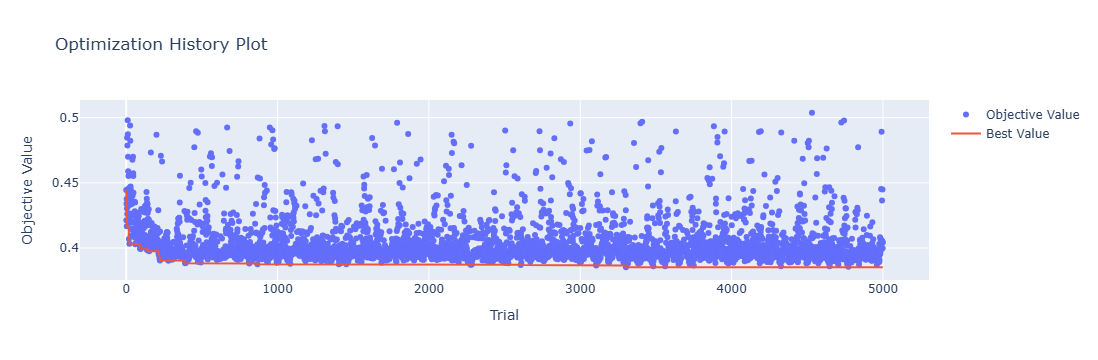

In [7]:
# Plot optimisation history
plot_optimization_history(study)

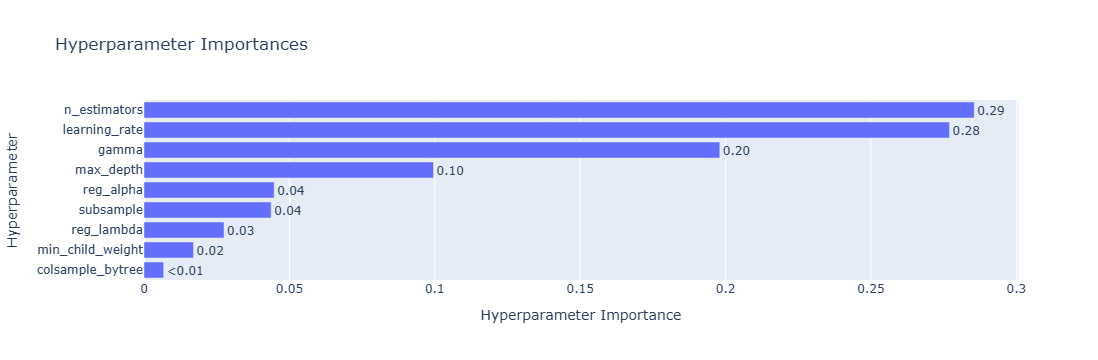

In [8]:
# Plot parameter importances
plot_param_importances(study)

In [9]:
# Print results
print("Best trial:")
print("  RMSE: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")


Best trial:
  RMSE:  0.385230044811395
  Params: 
    learning_rate: 0.267602233609805
    n_estimators: 411
    max_depth: 1
    min_child_weight: 8
    gamma: 5.982882657246751e-07
    subsample: 0.9408045592657599
    colsample_bytree: 0.7958154359747472
    reg_alpha: 0.5526830865916027
    reg_lambda: 7.705243118114542


## Fit the model to data

In [10]:
scaler = ScalingHandler(scaling_method='standard')
# Final evaluation with CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_predictions = []
actual_values = []
metrics_per_fold = []
shap_values_per_fold = []
fold_models = []  # Store models if needed later
perm_importance_results = [] # List to store permutation importance results

for fold, (train_idx, test_idx) in enumerate(cv.split(df[feature_cols])):
    train_fold = df.iloc[train_idx]
    test_fold = df.iloc[test_idx]

    train_scaled, test_scaled = scaler.scale_data(train_fold, test_fold, cont_names)
    # XGBoost
    best_xgb = xgb.XGBRegressor(**study.best_trial.params,  random_state = 11)
    best_xgb.fit(
        train_scaled[feature_cols],
        train_fold[target_col],
        eval_set=[(test_scaled[feature_cols], test_fold[target_col])],
        verbose=False
    )
    fold_models.append(best_xgb)

    # Calculate permutation importance for this fold
    result = permutation_importance(
        best_xgb, test_scaled[feature_cols], test_fold[target_col],
        n_repeats=10,
        random_state=42
    )
    
    # Store results for this fold
    fold_importance = pd.DataFrame({
        'feature': feature_cols,
        'PFI_values_mean': result.importances_mean,
        'Importance_Std': result.importances_std,
        'Fold': fold
    })
    perm_importance_results.append(fold_importance)
    
    xgb_pred = best_xgb.predict(test_scaled[feature_cols])
    fold_metrics = {
    'RMSE': np.sqrt(mean_squared_error(test_fold[target_col], xgb_pred)),
    'MAE': mean_absolute_error(test_fold[target_col], xgb_pred),
    'R2': r2_score(test_fold[target_col], xgb_pred),
    'MAPE': mean_absolute_percentage_error(test_fold[target_col], xgb_pred),
    'EVS': explained_variance_score(test_fold[target_col], xgb_pred)
    }
    metrics_per_fold.append(fold_metrics)

    # SHAP values for this fold
    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(test_scaled[feature_cols])
    shap_values_per_fold.append(shap_values)

    # Store predictions and actual values
    xgb_predictions.extend(xgb_pred)
    actual_values.extend(test_fold[target_col])


# Create DataFrame with all predictions
results_df = pd.DataFrame({
    'Actual': actual_values,
    'XGBoost_Pred': xgb_predictions,
})

## Model Performance

In [11]:
# Print results
print("Best model:") #best model after avg cross validation
for metric in fold_metrics.keys():
    values = [fold[metric] for fold in metrics_per_fold]
    print(f"XGBoost - Mean {metric}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

Best model:
XGBoost - Mean RMSE: 0.3963 (+/- 0.0509)
XGBoost - Mean MAE: 0.3149 (+/- 0.0415)
XGBoost - Mean R2: 0.2521 (+/- 0.3320)
XGBoost - Mean MAPE: 0.2596 (+/- 0.1103)
XGBoost - Mean EVS: 0.3039 (+/- 0.2970)
  Params: 
    learning_rate: 0.267602233609805
    n_estimators: 411
    max_depth: 1
    min_child_weight: 8
    gamma: 5.982882657246751e-07
    subsample: 0.9408045592657599
    colsample_bytree: 0.7958154359747472
    reg_alpha: 0.5526830865916027
    reg_lambda: 7.705243118114542


Text(0.5, 0, 'Targeted Feature Values')

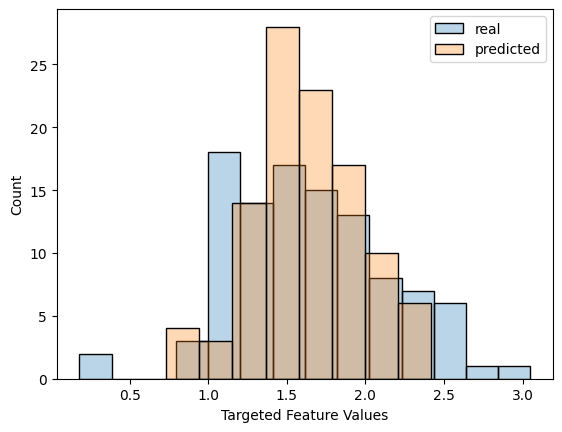

In [12]:
d,axs = pl.subplots()
sns.histplot (results_df.Actual, alpha=0.3, label = 'real', ax = axs, binwidth=0.2)
sns.histplot (results_df.XGBoost_Pred, alpha=0.3, label = 'predicted', ax=axs, binwidth=0.2)
axs.legend ()
axs.set_xlabel ("Targeted Feature Values")

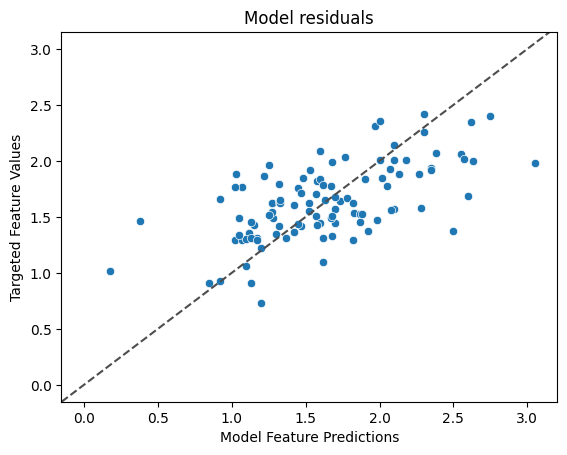

In [13]:
#plot residuals and check for linearity
f, ax = pl.subplots()
sns.scatterplot (y = results_df.XGBoost_Pred, x = results_df.Actual, ax = ax)
pl.title ("Model residuals")
pl.ylabel ("Targeted Feature Values")
pl.xlabel ("Model Feature Predictions")
pl.axline ([0,0], [3,3], ls="--", c=".3")

Text(0.5, 0, 'Residuals')

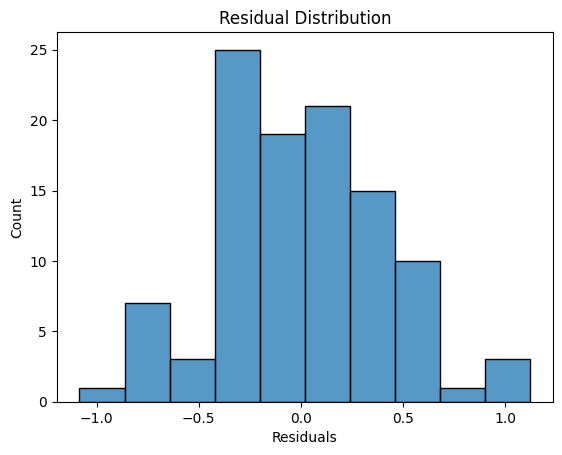

In [14]:
#visualise histogram of residuals
residuals = results_df.Actual-results_df.XGBoost_Pred
sns.histplot (residuals)
pl.title ("Residual Distribution")
pl.xlabel ("Residuals")

# Feature importance analysis

In [15]:
# Combine permutation importance results across folds
all_importance = pd.concat(perm_importance_results)
pfi_mean_importance = all_importance.groupby('feature', as_index=False).agg({
    'PFI_values_mean': 'mean',
    'Importance_Std': 'mean'
}).sort_values('PFI_values_mean', ascending=False)

print("\nMean Permutation Importance across folds:")
print(pfi_mean_importance)


Mean Permutation Importance across folds:
                             feature  PFI_values_mean  Importance_Std
4                     driverTraining         0.382986        0.173712
5                  drivingExperience         0.319098        0.126072
13             totalGlanceTimeOnRoad         0.175857        0.097880
7                        eventNumber         0.162832        0.093023
16                 yawGazeDispersion         0.149186        0.106562
0                                AVR         0.122624        0.101349
6            euclideanGazeDispersion         0.061306        0.068953
12            totalGlanceTimeOffRoad         0.047062        0.058747
2                             Gender         0.038849        0.052144
9                pitchGazeDispersion         0.029758        0.048784
8                        gazeEntropy         0.003369        0.064477
3                             attenD         0.000599        0.002541
14    totalGlanceTimePassengerMirror         0.

<ErrorbarContainer object of 3 artists>

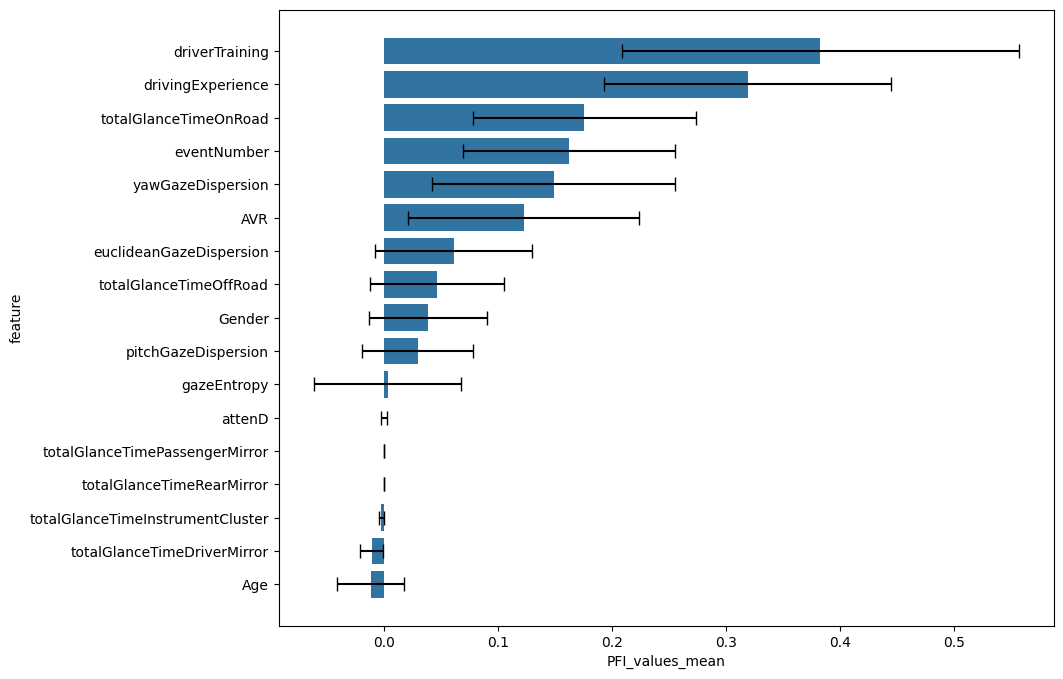

In [16]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x='PFI_values_mean',
    y=pfi_mean_importance.feature,
    data=pfi_mean_importance,
)

# Add error bars manually
plt.errorbar(
    x=pfi_mean_importance['PFI_values_mean'],
    y=range(len(pfi_mean_importance.index)),
    xerr=pfi_mean_importance['Importance_Std'],
    fmt='none',  # Don't add any markers
    color='black',
    capsize=5
)
    

In [17]:
# Average SHAP values across folds
all_shap_values = np.concatenate(shap_values_per_fold)
shap_df = pd.DataFrame(all_shap_values, columns=feature_cols)

# Calculate mean absolute SHAP values for feature importance
mean_abs_shap = np.abs(shap_df).mean()
shap_mean_feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap_value': mean_abs_shap.values
}).sort_values('mean_abs_shap_value', ascending=False)

In [18]:
shap_mean_feature_importance

,feature,mean_abs_shap_value
1,driverTraining,0.236832
4,drivingExperience,0.143942
9,yawGazeDispersion,0.116900
2,eventNumber,0.103706
14,totalGlanceTimeOnRoad,0.100859
5,AVR,0.096103
7,euclideanGazeDispersion,0.084971
13,totalGlanceTimeOffRoad,0.081090
8,gazeEntropy,0.078560
0,Gender,0.073110


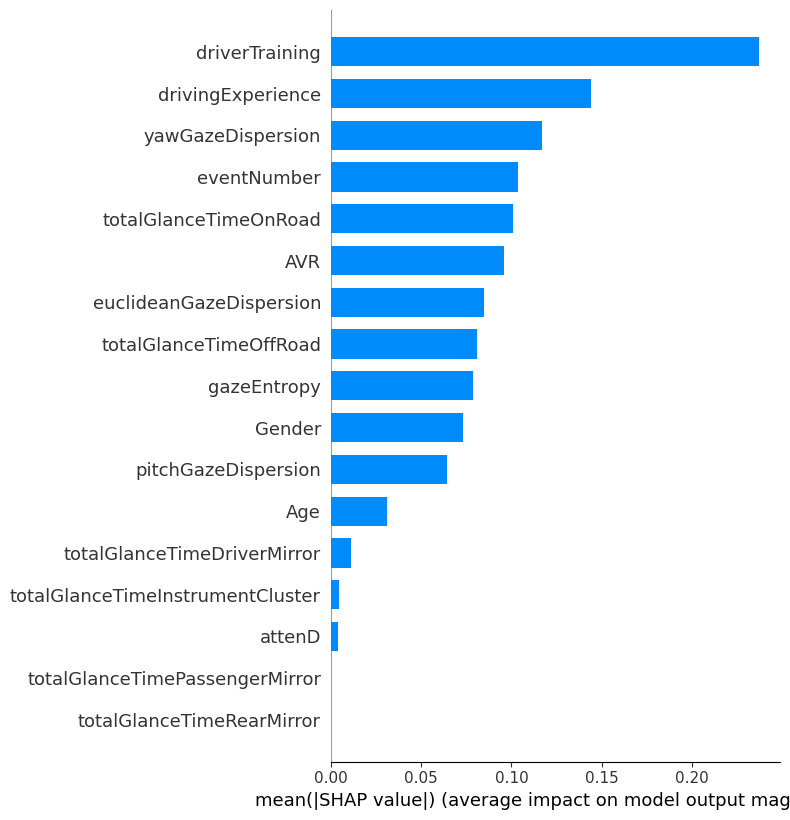

In [19]:
shap.summary_plot(all_shap_values, df[feature_cols], plot_type="bar")

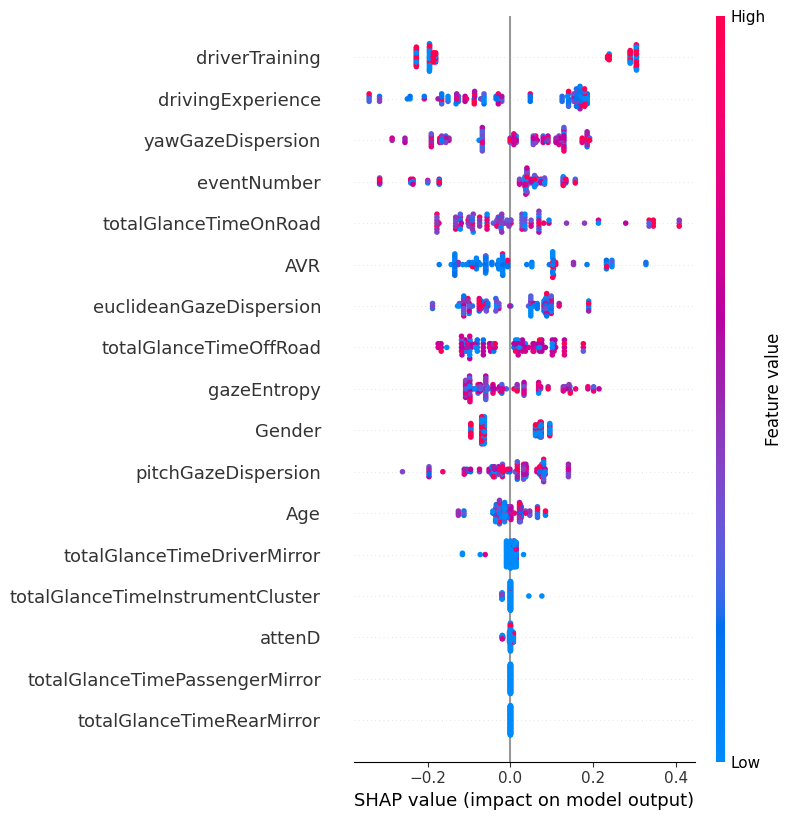

In [20]:
shap.summary_plot(all_shap_values, df[feature_cols])

In [21]:
def combine_shap_pfi_rankings(shap_importance_df, pfi_importance_df):
    """
    Combine SHAP and PFI rankings using rank averaging.
    """

    # Create rank columns (1 = most important)
    shap_df = shap_importance_df.copy()
    shap_df['shap_rank'] = shap_df['mean_abs_shap_value'].rank(ascending=False, method='min')

    pfi_df = pfi_importance_df.copy()
    pfi_df['pfi_rank'] = pfi_df['PFI_values_mean'].rank(ascending=False, method='min')

    # Merge on feature names
    combined = pd.merge(
        shap_df[['feature', 'shap_rank', 'mean_abs_shap_value']],
        pfi_df[['feature', 'pfi_rank', 'PFI_values_mean']],
        left_on='feature', right_on='feature'
    )

    # Average the ranks
    combined['average_rank'] = (combined['shap_rank'] + combined['pfi_rank']) / 2

    # Sort by average rank (lower = better)
    combined = combined.sort_values('average_rank')

    # Create a final importance score for compatibility with stepwise function
    # (just invert the rank so higher = more important)
    combined['combined_importance'] = len(combined) - combined['average_rank'] + 1

    # Clean up the output
    result = combined[['feature', 'average_rank', 'combined_importance',
                      'shap_rank', 'pfi_rank', 'mean_abs_shap_value', 'PFI_values_mean']]

    return result


def print_ranking_comparison(combined_df, top_n=15):
    print("=== FEATURE RANKING COMPARISON ===\n")
    print(f"{'Rank':<4} {'Feature':<25} {'SHAP':<6} {'PFI':<6} {'Avg':<6}")
    print("-" * 55)

    for i, row in combined_df.head(top_n).iterrows():
        print(f"{int(row.name + 1):<4} {row['feature']:<25} "
              f"{int(row['shap_rank']):<6} {int(row['pfi_rank']):<6} "
              f"{row['average_rank']:<6.1f}")

    print(f"\nShowing top {top_n} features by combined ranking")




combined_importance = combine_shap_pfi_rankings(shap_mean_feature_importance,
                                                pfi_mean_importance)
combined_importance


,feature,average_rank,combined_importance,shap_rank,pfi_rank,mean_abs_shap_value,PFI_values_mean
0,driverTraining,1.0,17.0,1.0,1.0,0.236832,0.382986
1,drivingExperience,2.0,16.0,2.0,2.0,0.143942,0.319098
2,yawGazeDispersion,4.0,14.0,3.0,5.0,0.116900,0.149186
3,eventNumber,4.0,14.0,4.0,4.0,0.103706,0.162832
4,totalGlanceTimeOnRoad,4.0,14.0,5.0,3.0,0.100859,0.175857
5,AVR,6.0,12.0,6.0,6.0,0.096103,0.122624
6,euclideanGazeDispersion,7.0,11.0,7.0,7.0,0.084971,0.061306
7,totalGlanceTimeOffRoad,8.0,10.0,8.0,8.0,0.081090,0.047062
9,Gender,9.5,8.5,10.0,9.0,0.073110,0.038849
8,gazeEntropy,10.0,8.0,9.0,11.0,0.078560,0.003369


In [22]:
results_df = results_df.rename(columns={'XGBoost_Pred': 'Pred'})
file = open ('PDRA_XGBoost.pickle', 'wb')
pickle.dump (best_xgb, file)
file.close
shap_df.to_pickle ('SHAP_Values_XGBoost.pkl')
results_df.to_pickle ('SHAP_Predictions_XGBoost.pkl')
combined_importance.to_pickle ('combined_importance_XGBoost.pkl')